# Supplementary: Baseline-corrected individual line profiles - ID16A

This notebook renders the multi-panel figure for the paper’s supplemen, Supp Figure S6:
- **Epon 1** (blue)
- **CPD 1–2** (red)

In [11]:
# ==== ID16A supplementary figure: baseline-corrected individual profiles (1×3) ====

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# --- File paths (edit) ---
file_path_1 = "/data/ID16A/ID16A_Epon_lineprofiles_SK186_p2_n100.csv"  # Epon
file_path_2 = "/data/ID16A/ID16A_CPD_lineprofiles_SK185_p1_n100.csv"  # CPD 1
file_path_3 = "/data/ID16A/ID16A_CPD_lineprofiles_SK120_n50.csv"       # CPD 2

OUT_SVG = "supp_corrected_profiles_ID16A.svg"

In [12]:
# --- Style ---
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "axes.linewidth": 1.5,
    "figure.dpi": 150
})

In [13]:
# --- Helpers ---
def safe_read_csv(p):
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing file: {p}")
    return pd.read_csv(p, header=None, low_memory=False)

def extract_dist_and_profiles_id16a(df, pixels_to_um=0.100):
    """
    ID16A:
      - distance (col 0) in pixels -> µm
      - profiles = every other col from col 1
      - convert ω [cm^-1] -> P14 units (rad/voxel) via factor 0.512*0.325*1e-4
      - no sign inversion
    """
    dist_um = df.iloc[:, 0].to_numpy(dtype=float) * pixels_to_um
    profs = df.iloc[:, 1::2].to_numpy(dtype=float)
    profs = profs * (0.512 * 0.325 * 1e-4)  # unit conversion
    return dist_um, profs

def baseline_correct_profiles(dist_um, profiles):
    """
    Per-profile baseline correction using windows: [0,1.8] ∪ [6.2,8] µm (your ID16A choice).
    """
    mask = ((dist_um >= 0.0) & (dist_um <= 1.8)) | ((dist_um >= 6.2) & (dist_um <= 8.0))
    corrected = np.empty_like(profiles)
    for i in range(profiles.shape[1]):
        base_mean = np.mean(profiles[mask, i])
        corrected[:, i] = profiles[:, i] - base_mean
    return corrected

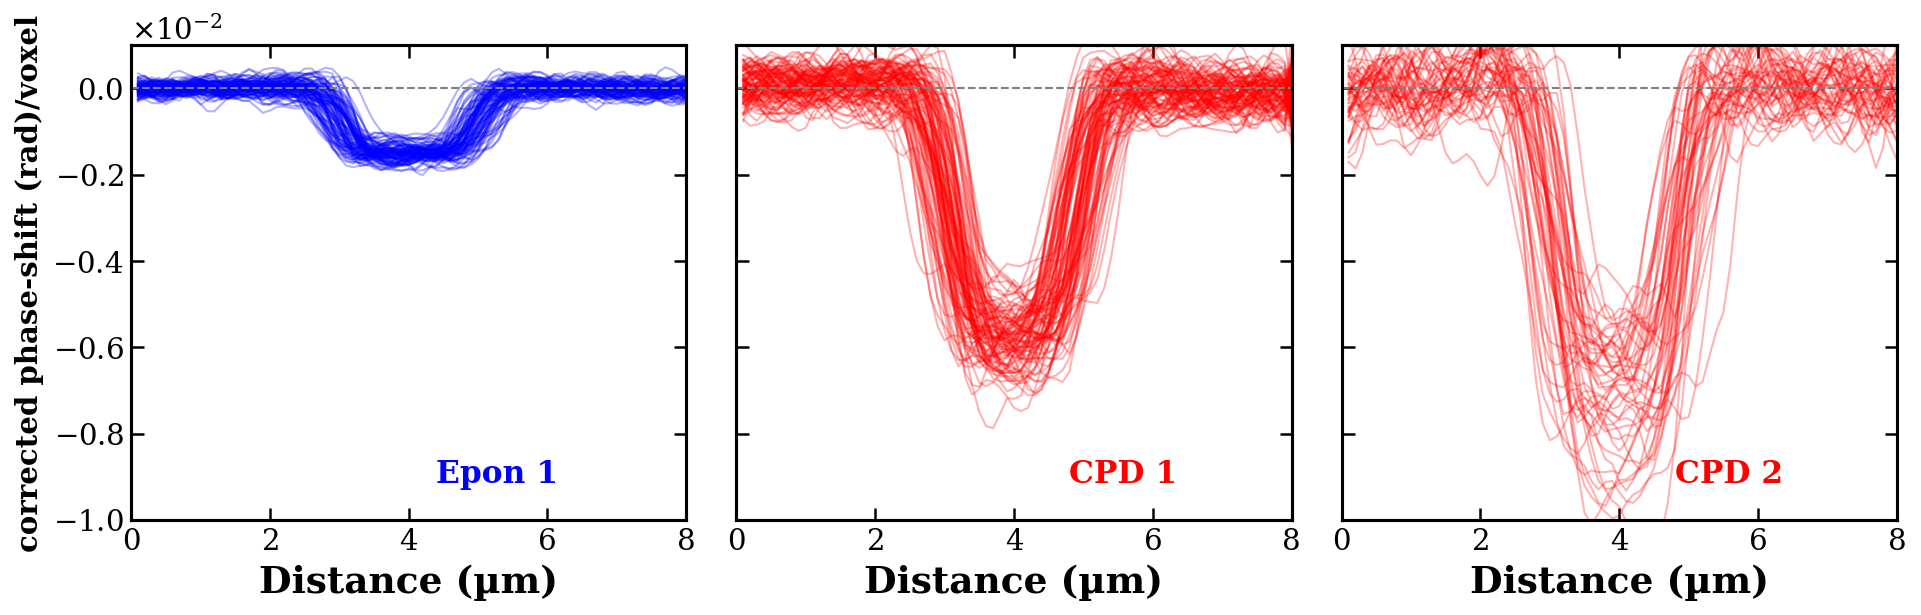

In [10]:
# --- Load/process datasets ---
paths = [file_path_1, file_path_2, file_path_3]
labels = ["Epon 1", "CPD 1", "CPD 2"]
colours = ["blue", "red", "red"]

processed = []
for p in paths:
    df = safe_read_csv(p)
    dist_um, profs = extract_dist_and_profiles_id16a(df)
    corr = baseline_correct_profiles(dist_um, profs)
    processed.append((dist_um, corr))

# --- Build figure (1×3) ---
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6), sharex=True, sharey=True)

# axis limits to match your visuals
X_LIMS = (0, 8)
Y_LIMS = (-1.0e-2, 1.0e-3)

for i, (ax, (dist_um, corr), label, color) in enumerate(zip(axes, processed, labels, colours)):
    for k in range(corr.shape[1]):
        ax.plot(dist_um, corr[:, k], color=color, alpha=0.30, linewidth=1)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    # panel tag
    x_text = 0.60 if color == "red" else 0.55
    ax.text(x_text, 0.08, label, color=color, fontsize=15, transform=ax.transAxes, fontweight="bold")

    # cosmetics
    ax.set_xlim(*X_LIMS)
    ax.set_ylim(*Y_LIMS)
    ax.tick_params(axis='both', direction='in', length=6, width=1.2, top=True, right=True)
    fmt = ScalarFormatter(useMathText=True)
    fmt.set_scientific(True)
    fmt.set_powerlimits((0, 0))  # always show ×10^n
    ax.yaxis.set_major_formatter(fmt)
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

# shared labels
axes[0].set_ylabel("corrected phase-shift (rad)/voxel", fontsize=14, fontweight="bold")
for ax in axes:
    ax.set_xlabel("Distance (µm)", fontsize=18, fontweight="bold")

plt.tight_layout(rect=[0.03, 0.02, 0.995, 0.96])
#plt.savefig(OUT_SVG, format="svg", dpi=600, bbox_inches="tight")
plt.show()

#print(f"Saved: {OUT_SVG}")